# MATH 5010 Computer Lab 20
## Bayesian Inference: From Prior to Posterior, Prediction, Testing, and Computation

**Full solutions included**

This lab is a capstone Bayesian inference lab for Section 20. It collects the Bayesian ideas that appeared in point estimation, interval estimation, hypothesis testing, ANOVA, and simulation.

### Main goals

By the end of this lab, you should be able to:

1. Use conjugate priors to derive posterior distributions.
2. Compute Bayes estimators under common loss functions.
3. Compute credible intervals and compare them with frequentist confidence intervals.
4. Carry out Bayesian hypothesis testing using posterior probabilities.
5. Compute posterior predictive distributions.
6. Use Monte Carlo simulation to approximate posterior summaries.
7. Implement a simple Gibbs sampler for a normal model with unknown mean and variance.

### Mathematical themes

The central Bayesian formula is

$$
\pi(\theta \mid x) \propto L(\theta;x)\pi(\theta),
$$

where $L(\theta;x)$ is the likelihood and $\pi(\theta)$ is the prior. A Bayesian answer usually comes from the posterior distribution $\pi(\theta\mid x)$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, special

rng = np.random.default_rng(5010)
np.set_printoptions(precision=4, suppress=True)

## 1. Beta-Binomial model for a proportion

Suppose

$$
X \mid p \sim \operatorname{Binomial}(n,p), \qquad p \sim \operatorname{Beta}(a,b).
$$

### Exercise 1

Let $n=100$, $x=62$, and prior $p\sim \operatorname{Beta}(2,2)$.

1. Derive the posterior distribution of $p$.
2. Compute the posterior mean, posterior median, posterior mode, posterior standard deviation, and a 95% credible interval.
3. Plot the prior and posterior densities.

### Solution

The likelihood is

$$
L(p;x) \propto p^x(1-p)^{n-x}.
$$

The prior is

$$
\pi(p) \propto p^{a-1}(1-p)^{b-1}.
$$

Therefore

$$
\pi(p\mid x) \propto p^{a+x-1}(1-p)^{b+n-x-1},
$$

so

$$
p\mid x \sim \operatorname{Beta}(a+x,b+n-x).
$$

In [2]:
n = 100
x = 62
a, b = 2, 2
post_a = a + x
post_b = b + n - x

post_mean = post_a / (post_a + post_b)
post_median = stats.beta.median(post_a, post_b)
post_mode = (post_a - 1) / (post_a + post_b - 2)
post_sd = stats.beta.std(post_a, post_b)
cred_int = stats.beta.ppf([0.025, 0.975], post_a, post_b)

summary = pd.DataFrame({
    'quantity': ['posterior alpha', 'posterior beta', 'mean', 'median', 'mode', 'sd', '2.5%', '97.5%'],
    'value': [post_a, post_b, post_mean, post_median, post_mode, post_sd, cred_int[0], cred_int[1]]
})
summary

,quantity,value
0,posterior alpha,64.000000
1,posterior beta,40.000000
2,mean,0.615385
3,median,0.616127
4,mode,0.617647
5,sd,0.047478
6,2.5%,0.520437
7,97.5%,0.706128


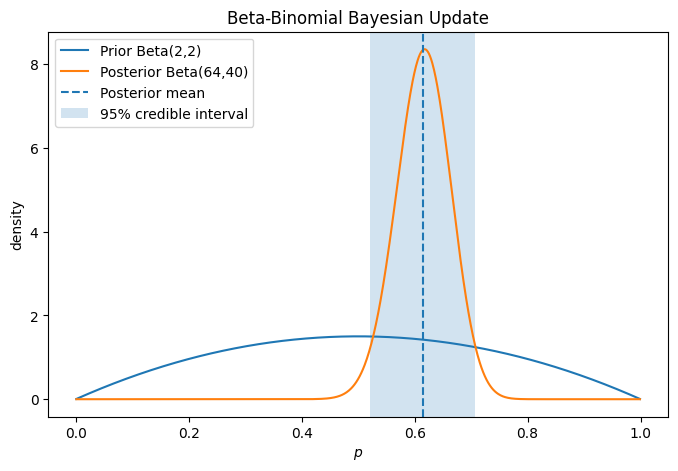

In [3]:
grid = np.linspace(0.001, 0.999, 1000)
prior_pdf = stats.beta.pdf(grid, a, b)
post_pdf = stats.beta.pdf(grid, post_a, post_b)

plt.figure(figsize=(8, 5))
plt.plot(grid, prior_pdf, label='Prior Beta(2,2)')
plt.plot(grid, post_pdf, label=f'Posterior Beta({post_a},{post_b})')
plt.axvline(post_mean, linestyle='--', label='Posterior mean')
plt.axvspan(cred_int[0], cred_int[1], alpha=0.2, label='95% credible interval')
plt.xlabel('$p$')
plt.ylabel('density')
plt.title('Beta-Binomial Bayesian Update')
plt.legend()
plt.show()

## 2. Bayes estimators under different loss functions

A Bayes estimator depends on the loss function.

For posterior distribution $\pi(\theta\mid x)$:

| Loss function | Bayes estimator |
|---|---|
| Squared error loss $(\theta-d)^2$ | Posterior mean $E[\theta\mid x]$ |
| Absolute error loss $|\theta-d|$ | Posterior median |
| 0-1 local loss | Posterior mode |

### Exercise 2

For the posterior $p\mid x\sim \operatorname{Beta}(64,40)$ from Exercise 1, report the Bayes estimators under squared error, absolute error, and 0-1 local loss.

### Solution

They are the posterior mean, median, and mode respectively.

In [4]:
bayes_estimators = pd.DataFrame({
    'loss': ['squared error', 'absolute error', '0-1 local loss'],
    'Bayes estimator': ['posterior mean', 'posterior median', 'posterior mode'],
    'value': [post_mean, post_median, post_mode]
})
bayes_estimators

,loss,Bayes estimator,value
0,squared error,posterior mean,0.615385
1,absolute error,posterior median,0.616127
2,0-1 local loss,posterior mode,0.617647


## 3. Bayesian testing for a binomial proportion

Suppose we want to test

$$
H_0:p\leq p_0 \qquad \text{versus} \qquad H_1:p>p_0.
$$

A Bayesian test can use posterior probability:

$$
P(H_0\mid x)=P(p\leq p_0\mid x).
$$

A simple Bayesian decision rule is:

$$
\text{Reject }H_0\text{ if }P(H_0\mid x)<0.05.
$$

### Exercise 3

Using the posterior from Exercise 1, test

$$
H_0:p\leq 0.5 \qquad \text{versus} \qquad H_1:p>0.5.
$$

Compute $P(H_0\mid x)$ and make a decision.

### Solution

Since $p\mid x\sim \operatorname{Beta}(64,40)$,

$$
P(H_0\mid x)=P(p\leq 0.5\mid x)=F_{\operatorname{Beta}(64,40)}(0.5).
$$

In [5]:
p0 = 0.5
post_prob_H0 = stats.beta.cdf(p0, post_a, post_b)
post_prob_H1 = 1 - post_prob_H0

decision = 'Reject H0' if post_prob_H0 < 0.05 else 'Do not reject H0'

pd.DataFrame({
    'quantity': ['P(H0 | data)', 'P(H1 | data)', 'decision rule', 'decision'],
    'value': [post_prob_H0, post_prob_H1, 'Reject if P(H0 | data) < 0.05', decision]
})

,quantity,value
0,P(H0 | data),0.008805
1,P(H1 | data),0.991195
2,decision rule,Reject if P(H0 | data) < 0.05
3,decision,Reject H0


## 4. Posterior predictive distribution: Beta-Binomial

The posterior predictive distribution answers questions about future observations.

If

$$
p\mid x \sim \operatorname{Beta}(\alpha_n,\beta_n),
$$

and

$$
Y\mid p \sim \operatorname{Binomial}(m,p),
$$

then

$$
Y\mid x \sim \operatorname{BetaBinomial}(m,\alpha_n,\beta_n).
$$

The predictive pmf is

$$
P(Y=y\mid x)
=\binom{m}{y}\frac{B(y+\alpha_n,m-y+\beta_n)}{B(\alpha_n,\beta_n)}.
$$

### Exercise 4

Using the posterior from Exercise 1, suppose there will be $m=20$ future trials. Compute:

1. The posterior predictive pmf of $Y$.
2. $E[Y\mid x]$ and $\operatorname{Var}(Y\mid x)$.
3. $P(Y\geq 15\mid x)$.

### Solution

Use the Beta-Binomial distribution with parameters $m=20$, $\alpha_n=64$, and $\beta_n=40$.

In [6]:
m = 20
ys = np.arange(m + 1)
# scipy.stats.betabinom uses parameters n, a, b
pred_pmf = stats.betabinom.pmf(ys, m, post_a, post_b)
pred_mean = stats.betabinom.mean(m, post_a, post_b)
pred_var = stats.betabinom.var(m, post_a, post_b)
prob_ge_15 = stats.betabinom.sf(14, m, post_a, post_b)

pd.DataFrame({
    'quantity': ['predictive mean', 'predictive variance', 'P(Y >= 15 | data)'],
    'value': [pred_mean, pred_var, prob_ge_15]
})

,quantity,value
0,predictive mean,12.307692
1,predictive variance,5.590307
2,P(Y >= 15 | data),0.179149


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5959/1483904029.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$P(Y=y\mid x)$')


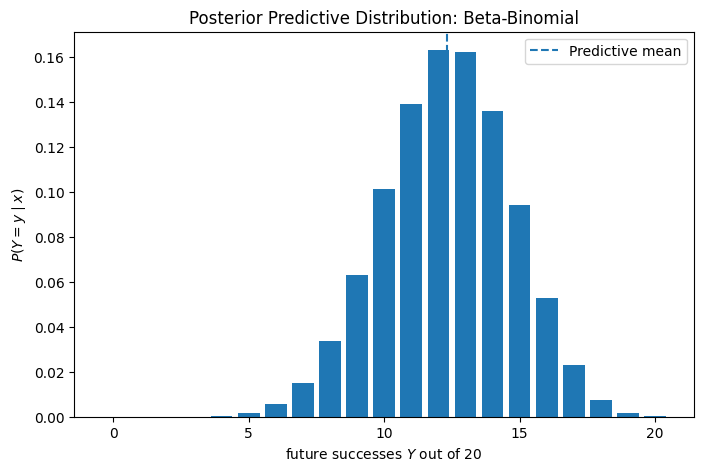

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(ys, pred_pmf)
plt.axvline(pred_mean, linestyle='--', label='Predictive mean')
plt.xlabel('future successes $Y$ out of 20')
plt.ylabel('$P(Y=y\mid x)$')
plt.title('Posterior Predictive Distribution: Beta-Binomial')
plt.legend()
plt.show()

## 5. Gamma-Poisson model for count data

Suppose

$$
X_1,\ldots,X_n\mid \lambda \overset{iid}{\sim} \operatorname{Poisson}(\lambda),
\qquad
\lambda\sim \operatorname{Gamma}(a,b),
$$

where $b$ is the rate parameter.

### Exercise 5

Let the observed counts be:

$$
4,5,3,7,6,2,4,8,5,6,4,7.
$$

Use prior $\lambda\sim \operatorname{Gamma}(2,1)$.

1. Derive the posterior distribution.
2. Compute posterior mean, mode, standard deviation, and 95% credible interval.
3. Test $H_0:\lambda\leq 5$ versus $H_1:\lambda>5$ using posterior probability.
4. Compute the posterior predictive probability that tomorrow's count is at least 8.

### Solution

The likelihood is

$$
L(\lambda;x)\propto \lambda^{\sum x_i}e^{-n\lambda}.
$$

The prior is

$$
\pi(\lambda)\propto \lambda^{a-1}e^{-b\lambda}.
$$

Thus

$$
\lambda\mid x\sim \operatorname{Gamma}\left(a+\sum_{i=1}^n x_i, b+n\right).
$$

In [8]:
counts = np.array([4,5,3,7,6,2,4,8,5,6,4,7])
n_counts = len(counts)
S_counts = counts.sum()
a0, b0 = 2, 1
post_shape = a0 + S_counts
post_rate = b0 + n_counts
post_scale = 1 / post_rate

pois_post_mean = post_shape / post_rate
pois_post_mode = (post_shape - 1) / post_rate if post_shape > 1 else np.nan
pois_post_sd = np.sqrt(post_shape) / post_rate
pois_cred = stats.gamma.ppf([0.025, 0.975], a=post_shape, scale=post_scale)
prob_lambda_le_5 = stats.gamma.cdf(5, a=post_shape, scale=post_scale)
pois_decision = 'Reject H0' if prob_lambda_le_5 < 0.05 else 'Do not reject H0'

# Posterior predictive for one future Poisson count under Gamma posterior is Negative Binomial.
# scipy nbinom parameterization: number of successes r, success probability p.
# If lambda ~ Gamma(alpha, rate beta), then Y ~ NegBin(r=alpha, p=beta/(beta+1)).
r = post_shape
p_success = post_rate / (post_rate + 1)
prob_future_ge_8 = stats.nbinom.sf(7, r, p_success)

pd.DataFrame({
    'quantity': ['n', 'sum counts', 'posterior shape', 'posterior rate', 'posterior mean', 'posterior mode',
                 'posterior sd', '2.5%', '97.5%', 'P(lambda <= 5 | data)', 'Bayesian decision', 'P(Y >= 8 | data)'],
    'value': [n_counts, S_counts, post_shape, post_rate, pois_post_mean, pois_post_mode,
              pois_post_sd, pois_cred[0], pois_cred[1], prob_lambda_le_5, pois_decision, prob_future_ge_8]
})

,quantity,value
0,n,12
1,sum counts,61
2,posterior shape,63
3,posterior rate,13
4,posterior mean,4.846154
5,posterior mode,4.769231
6,posterior sd,0.610558
7,2.5%,3.723918
8,97.5%,6.113939
9,P(lambda <= 5 | data),0.614574


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5959/2285575119.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.axvline(5, linestyle='--', label='$\lambda_0=5$')
/tmp/ipykernel_5959/2285575119.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$')


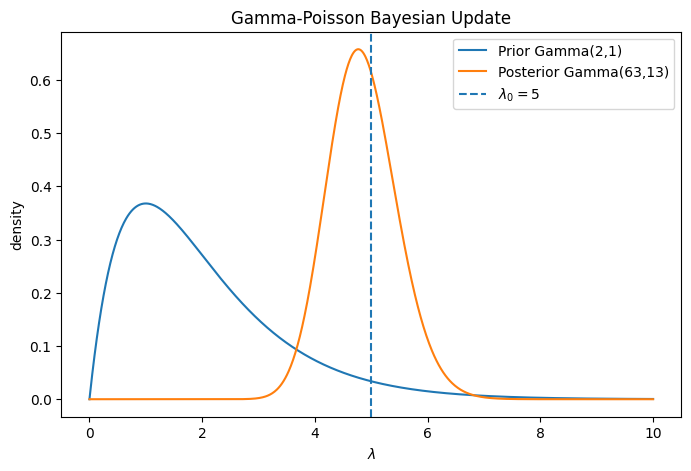

In [9]:
lam_grid = np.linspace(0, 10, 1000)
plt.figure(figsize=(8, 5))
plt.plot(lam_grid, stats.gamma.pdf(lam_grid, a=a0, scale=1/b0), label='Prior Gamma(2,1)')
plt.plot(lam_grid, stats.gamma.pdf(lam_grid, a=post_shape, scale=post_scale), label=f'Posterior Gamma({post_shape},{post_rate})')
plt.axvline(5, linestyle='--', label='$\lambda_0=5$')
plt.xlabel('$\lambda$')
plt.ylabel('density')
plt.title('Gamma-Poisson Bayesian Update')
plt.legend()
plt.show()

## 6. Inverse-Gamma posterior for an exponential mean

Suppose

$$
X_1,\ldots,X_n\mid \mu \overset{iid}{\sim}\operatorname{Exponential}(\mu),
$$

where $\mu$ is the mean, so

$$
f(x\mid \mu)=\frac{1}{\mu}e^{-x/\mu},\qquad x>0.
$$

Assume

$$
\mu\sim \operatorname{InvGamma}(a,b),
$$

with density proportional to

$$
\mu^{-(a+1)}e^{-b/\mu}.
$$

### Exercise 6

Use data generated below as waiting times. Use prior $\mu\sim\operatorname{InvGamma}(3,10)$.

1. Derive the posterior distribution.
2. Compute the posterior mean, median, mode, standard deviation, and 95% credible interval.
3. Test $H_0:\mu\leq 8$ versus $H_1:\mu>8$.

### Solution

The likelihood is

$$
L(\mu;x)\propto \mu^{-n}\exp\left(-\frac{\sum x_i}{\mu}\right).
$$

Combining with the prior gives

$$
\mu\mid x\sim \operatorname{InvGamma}\left(a+n,b+\sum_{i=1}^n x_i\right).
$$

In [10]:
waiting = np.array([7.2, 12.4, 4.5, 9.8, 15.1, 3.6, 8.7, 11.3, 6.9, 10.5, 13.6, 5.1, 14.2, 8.4, 9.1])
n_wait = len(waiting)
S_wait = waiting.sum()
a_ig, b_ig = 3, 10
post_a_ig = a_ig + n_wait
post_b_ig = b_ig + S_wait

# scipy invgamma: shape a and scale parameter = b
ig_mean = stats.invgamma.mean(a=post_a_ig, scale=post_b_ig)
ig_median = stats.invgamma.median(a=post_a_ig, scale=post_b_ig)
ig_mode = post_b_ig / (post_a_ig + 1)
ig_sd = stats.invgamma.std(a=post_a_ig, scale=post_b_ig)
ig_cred = stats.invgamma.ppf([0.025, 0.975], a=post_a_ig, scale=post_b_ig)
prob_mu_le_8 = stats.invgamma.cdf(8, a=post_a_ig, scale=post_b_ig)
ig_decision = 'Reject H0' if prob_mu_le_8 < 0.05 else 'Do not reject H0'

pd.DataFrame({
    'quantity': ['n', 'sum waiting times', 'posterior a', 'posterior b', 'posterior mean', 'posterior median',
                 'posterior mode', 'posterior sd', '2.5%', '97.5%', 'P(mu <= 8 | data)', 'Bayesian decision'],
    'value': [n_wait, S_wait, post_a_ig, post_b_ig, ig_mean, ig_median, ig_mode, ig_sd, ig_cred[0], ig_cred[1], prob_mu_le_8, ig_decision]
})

,quantity,value
0,n,15
1,sum waiting times,140.4
2,posterior a,18
3,posterior b,150.4
4,posterior mean,8.847059
5,posterior median,8.512668
6,posterior mode,7.915789
7,posterior sd,2.211765
8,2.5%,5.525624
9,97.5%,14.098316


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5959/312485807.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(8, linestyle='--', label='$\mu_0=8$')
/tmp/ipykernel_5959/312485807.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


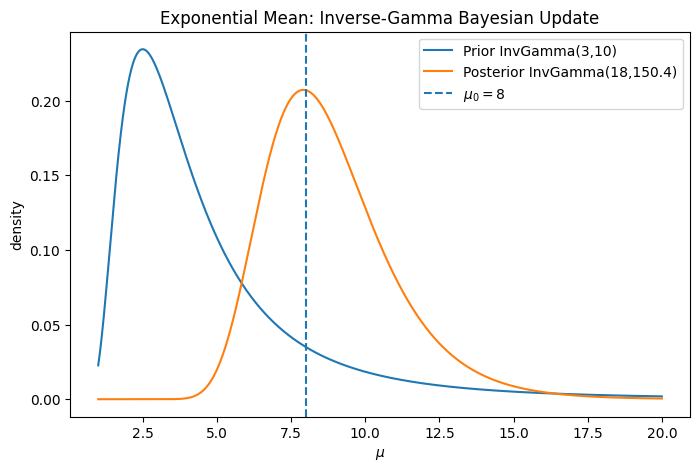

In [11]:
mu_grid = np.linspace(1, 20, 1000)
plt.figure(figsize=(8, 5))
plt.plot(mu_grid, stats.invgamma.pdf(mu_grid, a=a_ig, scale=b_ig), label='Prior InvGamma(3,10)')
plt.plot(mu_grid, stats.invgamma.pdf(mu_grid, a=post_a_ig, scale=post_b_ig), label=f'Posterior InvGamma({post_a_ig},{post_b_ig:.1f})')
plt.axvline(8, linestyle='--', label='$\mu_0=8$')
plt.xlabel('$\mu$')
plt.ylabel('density')
plt.title('Exponential Mean: Inverse-Gamma Bayesian Update')
plt.legend()
plt.show()

## 7. Normal mean with known variance

Suppose

$$
X_1,\ldots,X_n\mid \mu \overset{iid}{\sim}N(\mu,\sigma^2),
\qquad \sigma^2 \text{ known},
$$

and

$$
\mu\sim N(m_0,s_0^2).
$$

Then

$$
\mu\mid x\sim N(m_n,s_n^2),
$$

where

$$
\frac{1}{s_n^2}=\frac{1}{s_0^2}+\frac{n}{\sigma^2},
\qquad
m_n=s_n^2\left(\frac{m_0}{s_0^2}+\frac{n\bar{x}}{\sigma^2}\right).
$$

### Exercise 7

Assume $\sigma=3$, prior $\mu\sim N(50,10^2)$, and the observed sample below.

1. Compute the posterior distribution.
2. Compute a 95% credible interval for $\mu$.
3. Compute $P(\mu>52\mid x)$.
4. Compare the posterior mean with the sample mean and prior mean.

### Solution

Use the normal-normal conjugate formulas above.

In [12]:
normal_data = np.array([49.7, 52.8, 50.1, 55.4, 53.2, 51.8, 54.6, 52.3, 50.9, 53.7])
sigma = 3.0
m0 = 50.0
s0 = 10.0
n_norm = len(normal_data)
xbar_norm = normal_data.mean()

sn2 = 1 / (1/s0**2 + n_norm/sigma**2)
mn = sn2 * (m0/s0**2 + n_norm*xbar_norm/sigma**2)
sn = np.sqrt(sn2)
ci_mu = stats.norm.ppf([0.025, 0.975], loc=mn, scale=sn)
prob_mu_gt_52 = 1 - stats.norm.cdf(52, loc=mn, scale=sn)

pd.DataFrame({
    'quantity': ['prior mean', 'sample mean', 'posterior mean', 'posterior sd', '2.5%', '97.5%', 'P(mu > 52 | data)'],
    'value': [m0, xbar_norm, mn, sn, ci_mu[0], ci_mu[1], prob_mu_gt_52]
})

,quantity,value
0,prior mean,50.000000
1,sample mean,52.450000
2,posterior mean,52.428147
3,posterior sd,0.944443
4,2.5%,50.577073
5,97.5%,54.279221
6,P(mu > 52 | data),0.674845


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5959/484213105.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(52, linestyle=':', label='$\mu=52$')
/tmp/ipykernel_5959/484213105.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


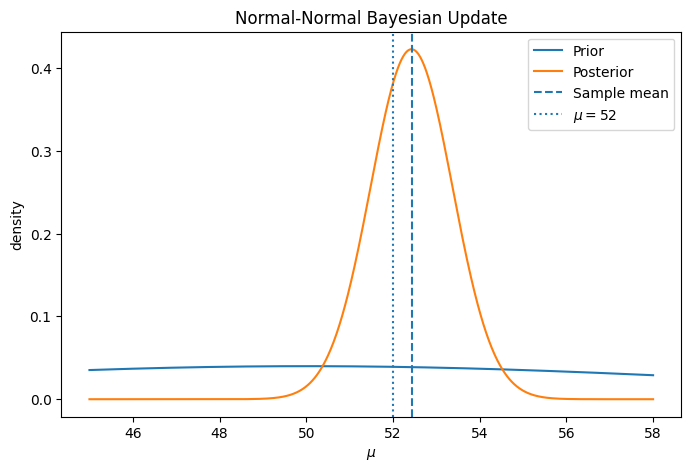

In [13]:
mu_grid = np.linspace(45, 58, 1000)
plt.figure(figsize=(8, 5))
plt.plot(mu_grid, stats.norm.pdf(mu_grid, loc=m0, scale=s0), label='Prior')
plt.plot(mu_grid, stats.norm.pdf(mu_grid, loc=mn, scale=sn), label='Posterior')
plt.axvline(xbar_norm, linestyle='--', label='Sample mean')
plt.axvline(52, linestyle=':', label='$\mu=52$')
plt.xlabel('$\mu$')
plt.ylabel('density')
plt.title('Normal-Normal Bayesian Update')
plt.legend()
plt.show()

## 8. Monte Carlo posterior approximation

For many Bayesian models, exact posterior formulas are unavailable. A general computational idea is:

1. Generate samples $\theta^{(1)},\ldots,\theta^{(M)}$ from the posterior.
2. Approximate posterior expectations by sample averages:

$$
E[g(\theta)\mid x]\approx \frac{1}{M}\sum_{m=1}^M g(\theta^{(m)}).
$$

### Exercise 8

Use Monte Carlo samples from the Beta posterior in Exercise 1 to approximate:

1. $E[p\mid x]$.
2. $P(p>0.6\mid x)$.
3. A 95% credible interval.

Compare with exact values.

### Solution

Draw many samples from $\operatorname{Beta}(64,40)$ and compute empirical summaries.

In [14]:
M = 100_000
p_samples = rng.beta(post_a, post_b, size=M)
mc_mean = p_samples.mean()
mc_prob_gt_06 = np.mean(p_samples > 0.6)
mc_ci = np.quantile(p_samples, [0.025, 0.975])

exact_prob_gt_06 = 1 - stats.beta.cdf(0.6, post_a, post_b)
exact_ci = stats.beta.ppf([0.025, 0.975], post_a, post_b)

pd.DataFrame({
    'quantity': ['mean', 'P(p > 0.6)', '2.5%', '97.5%'],
    'Monte Carlo': [mc_mean, mc_prob_gt_06, mc_ci[0], mc_ci[1]],
    'Exact': [post_mean, exact_prob_gt_06, exact_ci[0], exact_ci[1]]
})

,quantity,Monte Carlo,Exact
0,mean,0.615369,0.615385
1,P(p > 0.6),0.633310,0.631454
2,2.5%,0.520335,0.520437
3,97.5%,0.706160,0.706128


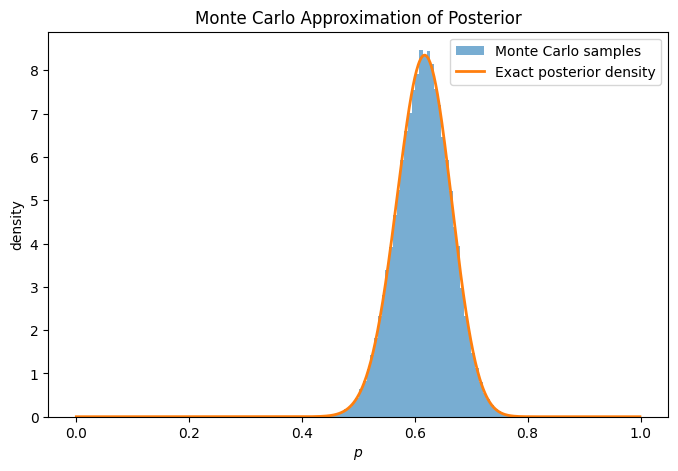

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(p_samples, bins=60, density=True, alpha=0.6, label='Monte Carlo samples')
plt.plot(grid, post_pdf, linewidth=2, label='Exact posterior density')
plt.xlabel('$p$')
plt.ylabel('density')
plt.title('Monte Carlo Approximation of Posterior')
plt.legend()
plt.show()

## 9. Gibbs sampler for a normal model with unknown mean and variance

Now consider a model where both $\mu$ and $\sigma^2$ are unknown:

$$
X_i\mid \mu,\sigma^2 \sim N(\mu,\sigma^2).
$$

Use the conjugate prior

$$
\mu\mid \sigma^2 \sim N\left(m_0,\frac{\sigma^2}{\kappa_0}\right),
\qquad
\sigma^2\sim \operatorname{InvGamma}(a_0,b_0).
$$

The Gibbs sampler alternates between the full conditional distributions:

$$
\mu\mid \sigma^2,x \sim N\left(m_n,\frac{\sigma^2}{\kappa_n}\right),
$$

where

$$
\kappa_n=\kappa_0+n,
\qquad
m_n=\frac{\kappa_0m_0+n\bar{x}}{\kappa_0+n},
$$

and

$$
\sigma^2\mid \mu,x\sim \operatorname{InvGamma}\left(a_0+\frac{n}{2},
 b_0+\frac{1}{2}\sum_{i=1}^n(x_i-\mu)^2+\frac{\kappa_0}{2}(\mu-m_0)^2\right).
$$

### Exercise 9

Use the sample below and run a Gibbs sampler for the unknown normal mean and variance.

1. Plot trace plots for $\mu$ and $\sigma$.
2. Estimate posterior means and 95% credible intervals.
3. Estimate $P(\mu>52\mid x)$.

### Solution

We implement the two conditional sampling steps directly.

In [16]:
xdata = normal_data.copy()
n = len(xdata)
xbar = xdata.mean()

m0 = 50.0
kappa0 = 1.0
a0 = 2.0
b0 = 10.0

n_iter = 12000
burn = 2000

mu_chain = np.empty(n_iter)
sigma2_chain = np.empty(n_iter)

mu_current = xbar
sigma2_current = xdata.var(ddof=1)

kappa_n = kappa0 + n
m_n_const = (kappa0 * m0 + n * xbar) / kappa_n
shape_sigma = a0 + n / 2

for t in range(n_iter):
    # sample mu | sigma2, x
    mu_sd = np.sqrt(sigma2_current / kappa_n)
    mu_current = rng.normal(m_n_const, mu_sd)
    
    # sample sigma2 | mu, x
    scale_sigma = b0 + 0.5 * np.sum((xdata - mu_current)**2) + 0.5 * kappa0 * (mu_current - m0)**2
    sigma2_current = stats.invgamma.rvs(a=shape_sigma, scale=scale_sigma, random_state=rng)
    
    mu_chain[t] = mu_current
    sigma2_chain[t] = sigma2_current

mu_post = mu_chain[burn:]
sigma_post = np.sqrt(sigma2_chain[burn:])

pd.DataFrame({
    'quantity': ['posterior mean of mu', 'mu 2.5%', 'mu 97.5%', 'posterior mean of sigma', 'sigma 2.5%', 'sigma 97.5%', 'P(mu > 52 | data)'],
    'value': [mu_post.mean(), np.quantile(mu_post, 0.025), np.quantile(mu_post, 0.975),
              sigma_post.mean(), np.quantile(sigma_post, 0.025), np.quantile(sigma_post, 0.975),
              np.mean(mu_post > 52)]
})

,quantity,value
0,posterior mean of mu,52.236818
1,mu 2.5%,50.915449
2,mu 97.5%,53.602411
3,posterior mean of sigma,2.231854
4,sigma 2.5%,1.527303
5,sigma 97.5%,3.360705
6,P(mu > 52 | data),0.636400


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5959/906193933.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mu$')
/tmp/ipykernel_5959/906193933.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Trace Plot for $\mu$')


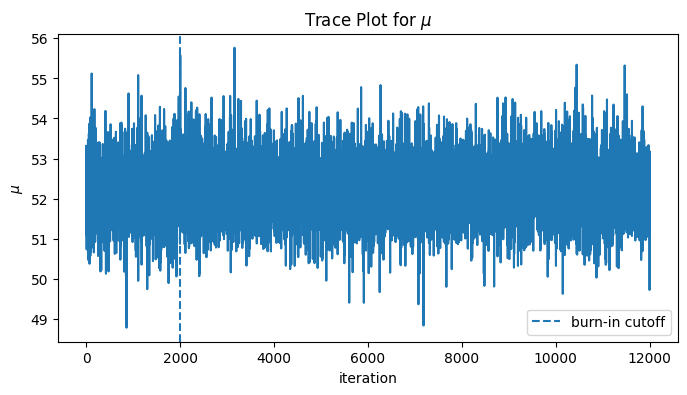

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(mu_chain)
plt.axvline(burn, linestyle='--', label='burn-in cutoff')
plt.xlabel('iteration')
plt.ylabel('$\mu$')
plt.title('Trace Plot for $\mu$')
plt.legend()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5959/1446615841.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma$')
/tmp/ipykernel_5959/1446615841.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Trace Plot for $\sigma$')


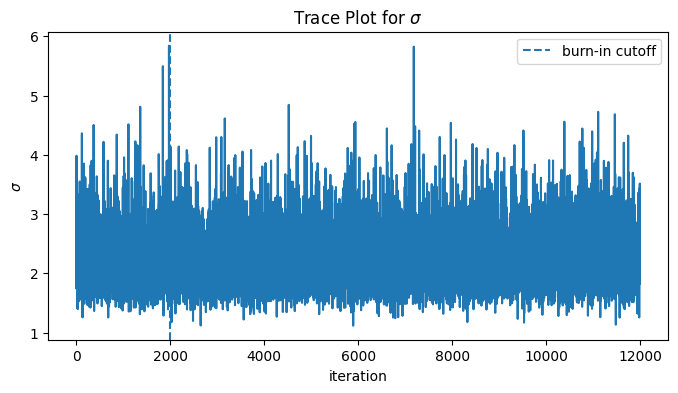

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(np.sqrt(sigma2_chain))
plt.axvline(burn, linestyle='--', label='burn-in cutoff')
plt.xlabel('iteration')
plt.ylabel('$\sigma$')
plt.title('Trace Plot for $\sigma$')
plt.legend()
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5959/1653878123.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(52, linestyle=':', label='$\mu=52$')
/tmp/ipykernel_5959/1653878123.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')
/tmp/ipykernel_5959/1653878123.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Posterior Samples for $\mu$')


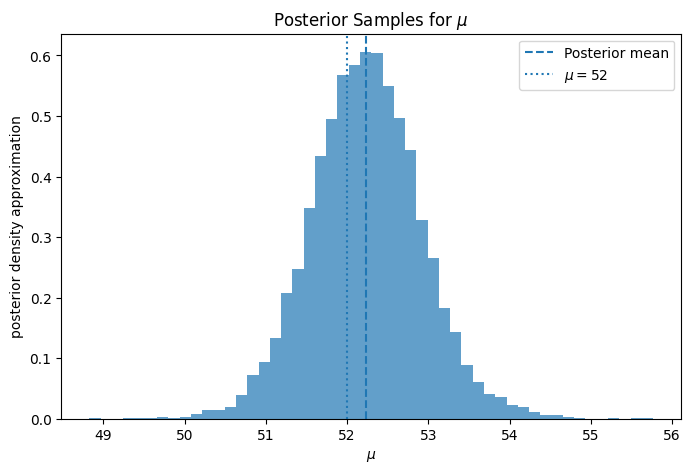

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(mu_post, bins=50, density=True, alpha=0.7)
plt.axvline(np.mean(mu_post), linestyle='--', label='Posterior mean')
plt.axvline(52, linestyle=':', label='$\mu=52$')
plt.xlabel('$\mu$')
plt.ylabel('posterior density approximation')
plt.title('Posterior Samples for $\mu$')
plt.legend()
plt.show()

## 10. Bayesian credible interval versus frequentist confidence interval

A frequentist 95% confidence interval is a procedure whose long-run coverage is 95%.

A Bayesian 95% credible interval means the posterior probability that the parameter lies inside the interval is 95%, conditional on the observed data and prior.

### Exercise 10

For the binomial example $x=62$, $n=100$:

1. Compute the Bayesian 95% credible interval using prior $\operatorname{Beta}(2,2)$.
2. Compute the approximate frequentist Wald confidence interval.
3. Compare the intervals.

### Solution

The Bayesian interval is obtained from posterior Beta quantiles. The Wald interval is

$$
\hat p\pm 1.96\sqrt{\frac{\hat p(1-\hat p)}{n}}.
$$

In [20]:
phat = x / n
wald_ci = phat + stats.norm.ppf([0.025, 0.975]) * np.sqrt(phat * (1 - phat) / n)
comparison = pd.DataFrame({
    'method': ['Bayesian credible interval Beta(2,2)', 'Frequentist Wald confidence interval'],
    'lower': [cred_int[0], wald_ci[0]],
    'upper': [cred_int[1], wald_ci[1]],
    'center': [post_mean, phat]
})
comparison

/tmp/ipykernel_5959/4294726519.py:2: RuntimeWarning: invalid value encountered in sqrt
  wald_ci = phat + stats.norm.ppf([0.025, 0.975]) * np.sqrt(phat * (1 - phat) / n)


,method,lower,upper,center
0,"Bayesian credible interval Beta(2,2)",0.520437,0.706128,0.615385
1,Frequentist Wald confidence interval,NaN,NaN,6.200000


## 11. Sensitivity to the prior

A good Bayesian analysis should check how much conclusions depend on the prior.

### Exercise 11

For the binomial data $x=62$, $n=100$, compare the following priors:

1. Uniform prior: $\operatorname{Beta}(1,1)$.
2. Jeffreys prior: $\operatorname{Beta}(1/2,1/2)$.
3. Mildly skeptical prior centered at 0.5: $\operatorname{Beta}(10,10)$.
4. Informative prior favoring high success probability: $\operatorname{Beta}(20,10)$.

For each prior, compute posterior mean, 95% credible interval, and $P(p>0.5\mid x)$.

### Solution

For each prior $\operatorname{Beta}(a,b)$, the posterior is

$$
\operatorname{Beta}(a+x,b+n-x).
$$

In [21]:
priors = [
    ('Uniform Beta(1,1)', 1, 1),
    ('Jeffreys Beta(0.5,0.5)', 0.5, 0.5),
    ('Skeptical Beta(10,10)', 10, 10),
    ('High prior Beta(20,10)', 20, 10),
]
rows = []
for name, aa, bb in priors:
    A = aa + x
    B = bb + n - x
    ci = stats.beta.ppf([0.025, 0.975], A, B)
    rows.append({
        'prior': name,
        'posterior': f'Beta({A:.1f}, {B:.1f})',
        'posterior mean': A / (A + B),
        '2.5%': ci[0],
        '97.5%': ci[1],
        'P(p > 0.5 | data)': 1 - stats.beta.cdf(0.5, A, B)
    })

sensitivity = pd.DataFrame(rows)
sensitivity

,prior,posterior,posterior mean,2.5%,97.5%,P(p > 0.5 | data)
0,"Uniform Beta(1,1)","Beta(63.0, -51.0)",5.250000,NaN,NaN,NaN
1,"Jeffreys Beta(0.5,0.5)","Beta(62.5, -51.5)",5.681818,NaN,NaN,NaN
2,"Skeptical Beta(10,10)","Beta(72.0, -42.0)",2.400000,NaN,NaN,NaN
3,"High prior Beta(20,10)","Beta(82.0, -42.0)",2.050000,NaN,NaN,NaN


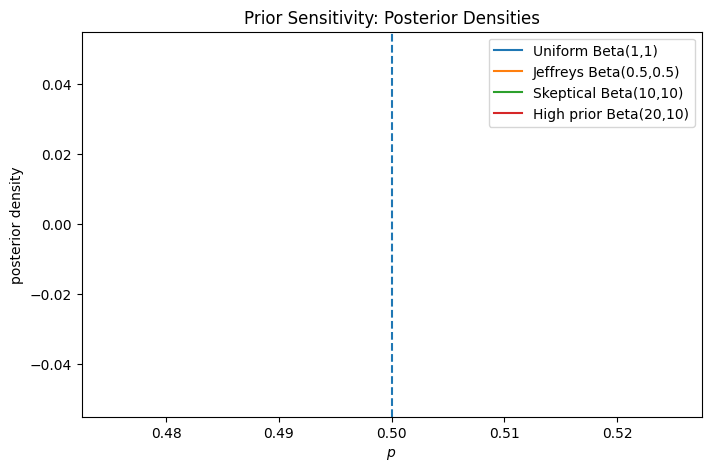

In [22]:
plt.figure(figsize=(8, 5))
for name, aa, bb in priors:
    A = aa + x
    B = bb + n - x
    plt.plot(grid, stats.beta.pdf(grid, A, B), label=name)
plt.axvline(0.5, linestyle='--')
plt.xlabel('$p$')
plt.ylabel('posterior density')
plt.title('Prior Sensitivity: Posterior Densities')
plt.legend()
plt.show()

## 12. Final synthesis questions

### Exercise 12

Answer these concept questions.

1. What is the likelihood principle in Bayesian inference?
2. Why do conjugate priors make Bayesian inference easier?
3. What is the difference between a confidence interval and a credible interval?
4. What does a posterior predictive distribution describe?
5. Why do we use MCMC methods such as Gibbs sampling?

### Solutions

1. **Likelihood principle:** Once data are observed, all information about the parameter from the data is contained in the likelihood function, up to proportionality. In Bayesian inference, the posterior is proportional to likelihood times prior.

2. **Conjugate priors:** A conjugate prior is chosen so that the posterior is in the same family as the prior. This gives closed-form posterior distributions and makes computation easier.

3. **Confidence interval versus credible interval:** A confidence interval is a random interval procedure with long-run coverage. A credible interval is an interval with a specified posterior probability conditional on the observed data and prior.

4. **Posterior predictive distribution:** It describes uncertainty about future data after incorporating both parameter uncertainty and sampling variability.

5. **MCMC:** We use MCMC when the posterior distribution is too complicated to compute or sample from directly. MCMC produces approximate posterior samples that can be used to estimate posterior summaries.

# End of Lab 20

## What to submit

Because this is a full-solution version, students may submit:

1. The completed notebook.
2. A short written summary of the Bayesian workflow.
3. Interpretations of the posterior probabilities, credible intervals, and predictive distributions in Exercises 3, 4, 5, 6, 9, and 11.

## Big picture

Bayesian inference follows one repeated pattern:

$$
\text{Prior belief} + \text{Data likelihood} \longrightarrow \text{Posterior belief}.
$$

Then the posterior can be used for point estimation, uncertainty quantification, hypothesis testing, prediction, and decision-making.